# Practical 3: Using Cartopy For Mapping

## Elsie Chilwane (CHLMOT003)
### SEA4001W
### 13/03/2026
###  Marcello Vichi

In [104]:
# Import all the needed packages:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature

from geopy.geocoders import Nominatim
from geopy.distance import geodesic

import matplotlib.ticker as mticker

## Part 1 : Antarctica and the Southern Ocean

The chosen map projection is the **South Polar Stereographic projection**.

It was used because it centrally visualises Antarctica and the surrounding Southern Ocean, which minimises the distortion in the polar region. It is also a projection that matches the one widely used in Antarctic research because it allows the continent to be fully represented clearly. So, this projection strongly mirrors the figures used in published Antarctic research.

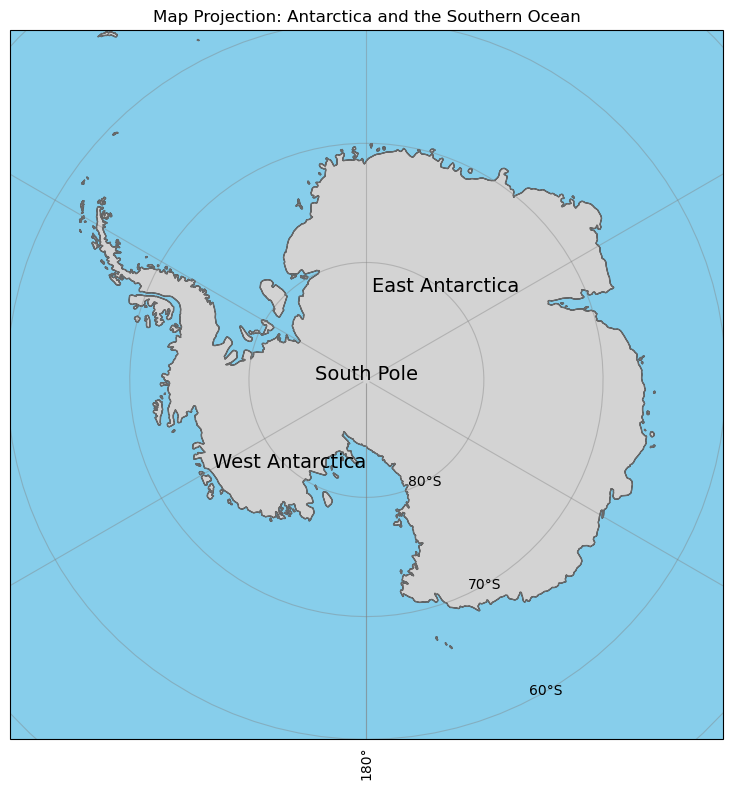

In [89]:
# The Southern Ocean and Antarctica 

# Create the figure and insert the size: 
fig = plt.figure(figsize=(10,8))

# Chosen Projection:
ax = plt.axes(projection=ccrs.SouthPolarStereo())

# Define the axes
ax.coastlines(linewidth = 0.8)

# Define the extent for our question
extent = [-180, 180, -90,-60]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add some gridlines:
gl = ax.gridlines(draw_labels=True, alpha = 0.4, color = 'gray')
gl.right_labels=False
gl.top_labels=False

# Adding some features to the map: 
ax.add_feature(cartopy.feature.LAND, facecolor= 'lightgray')
ax.add_feature(cartopy.feature.OCEAN, facecolor="skyblue")
ax.add_feature(cartopy.feature.COASTLINE, edgecolor = 'dimgray')

# Add text: 
ax.text(0, -90, 'South Pole', fontsize=14, ha='center', transform=ccrs.PlateCarree())
ax.text(60, -75, 'East Antarctica', fontsize=14, ha='right', transform=ccrs.PlateCarree())
ax.text(-120, -75, 'West Antarctica', fontsize=14, ha='left', transform=ccrs.PlateCarree())

# Plotting features
plt.title("Map Projection: Antarctica and the Southern Ocean")
plt.tight_layout()
plt.savefig('Map_Projection_Antarctica_and_the_Southern_Ocean.png', dpi = 300)
plt.show()


**Figure 1**: SouthPolarStereo Map Projection of Antarctica and the Southern Ocean. This figure illustrates the entire South Pole region from 60° southward. 

## Part 2: South Atlantic Cities Map
The chosen map projection is the **EqualEarth projection.**

It was chosen to visualise these coastal cities because it preserves the area across the map. This allows the 'true' spatial relationship between the African continent and the South American continent to be represented without distorting the 1) Ocean's size and 2) the 'actual' size of the continents.

[Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Rio de Janeiro, Região Geográfica Imediata do Rio de Janeiro, Região Metropolitana do Rio de Janeiro, Região Geográfica Intermediária do Rio de Janeiro, Rio de Janeiro, Região Sudeste, Brasil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


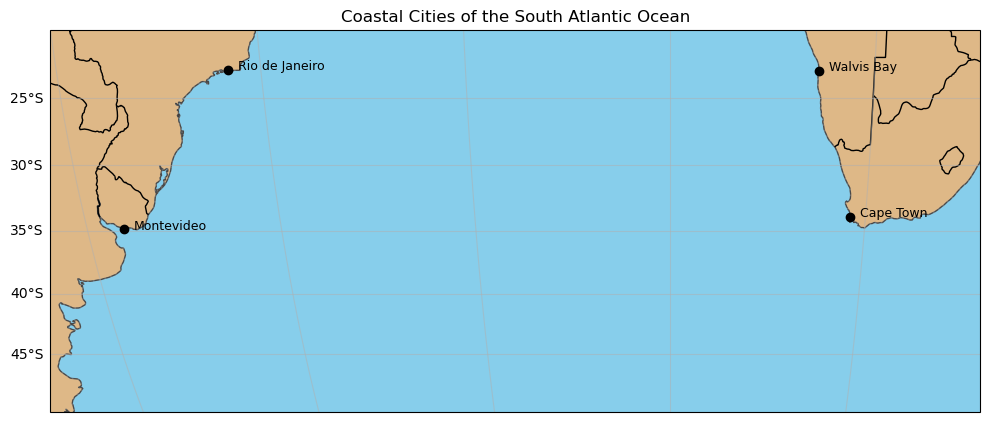

In [99]:

# Create figure
fig = plt.figure(figsize=(10,8))

# Insert Equal Earth projection
ax = plt.axes(projection=ccrs.EqualEarth())

# Extent
extent_2 = [-60, 30, -50, -20]
ax.set_extent(extent_2, crs=ccrs.PlateCarree())

# Add Map features
ax.add_feature(cartopy.feature.LAND, facecolor='burlywood')
ax.add_feature(cartopy.feature.OCEAN, facecolor='skyblue')
ax.add_feature(cartopy.feature.COASTLINE, edgecolor='dimgray')
ax.add_feature(cartopy.feature.BORDERS, edgecolor='black')

# Add Coastlines
ax.coastlines(linewidth=0.8, linestyle='--', alpha=0.3)

# Gridlines 
gl = ax.gridlines(draw_labels=True, alpha=0.5)

gl.top_labels = False
gl.bottom_labels = False
gl.right_labels = False
gl.left_labels = True

# Geocoder
geolocator = Nominatim(user_agent='map')

# Cities
places = ['Cape Town', 'Walvis Bay', 'Rio de Janeiro', 'Montevideo']

address = []

# Locate cities
for place in places:
    loc = geolocator.geocode(place)
    address.append(loc)

print(address)

# Plot cities
for loc in address:

    ax.plot(loc.longitude,
            loc.latitude,
            marker='o',
            color='black',
            markersize=6,
            transform=ccrs.PlateCarree())

    ax.text(loc.longitude + 1,
            loc.latitude,
            loc.address.split(',')[0],
            fontsize=9,
            transform=ccrs.PlateCarree())

# Title of the figure
plt.title('Coastal Cities of the South Atlantic Ocean')

plt.tight_layout()
plt.show()

**Figure 2**: Equal Earth Map Projection of Coastal Cities between Southern Africa and South America. This figure illustrates the maintained distance between the cities and the South Atlantic Ocean. 

## Part 3: False Bay Resolution Map
The chosen map projection is **the Mercator projection.**

This projection was used for False Bay to maintain the comparison of the False Bay region under different resolutions. At a local scale, Mercator's distortion is minimal, while the projection preserves the shape of the coastlines effectively. From the GSHHG dataset, the differences in the coastlines are sharper to observe without introducing significant projection distortion

<Figure size 640x480 with 0 Axes>

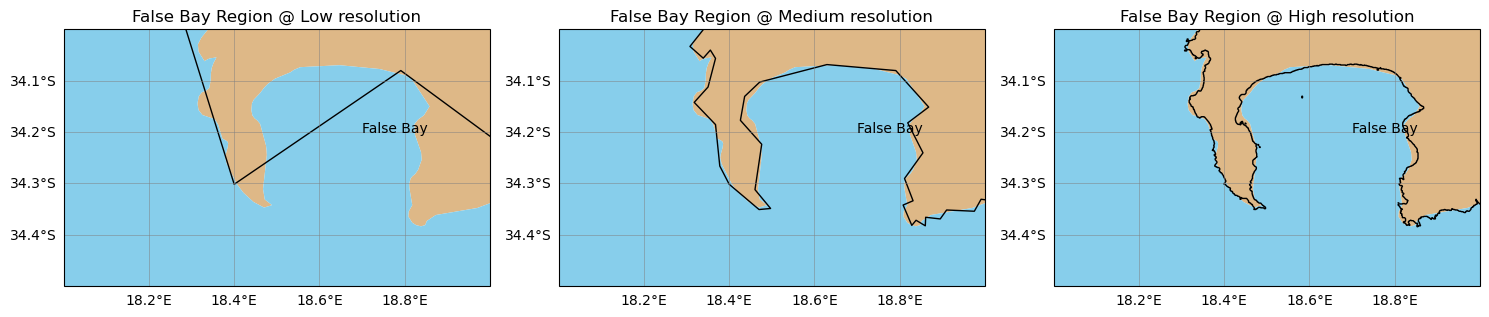

In [112]:

# Plot the figure:
plt.figure()

# Create the extent for the question: 
extent_3 = [18, 19, -34.5, -34]

# Set the figure parameters:
fig, ax = plt.subplots(
    1, 3, 
    figsize=(15,10),
    subplot_kw={'projection':ccrs.Mercator()})

# Plot 1 
ax[0].set_extent(extent_3, crs=ccrs.PlateCarree())
ax[0].add_feature(cfeature.LAND, facecolor='burlywood')
ax[0].add_feature(cfeature.OCEAN, facecolor='skyblue')

# Plot 1 Title
ax[0].set_title('False Bay Region @ Low resolution')
ax[0].text(18.7, -34.2, 'False Bay', transform=ccrs.PlateCarree())

# Plot 1 Resolution
coast_low = cfeature.GSHHSFeature(scale='c')
ax[0].add_feature(coast_low, edgecolor='black')

# Plot 1 Gridlines
gl0 = ax[0].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
gl0.top_labels = False
gl0.right_labels = False
gl0.left_labels = True
gl0.bottom_labels = True
gl0.xlocator = mticker.FixedLocator([18, 18.2, 18.4, 18.6, 18.8, 19])
gl0.ylocator = mticker.FixedLocator([-34.5, -34.4, -34.3, -34.2, -34.1, -34])

# Plot 2
ax[1].set_extent(extent_3, crs=ccrs.PlateCarree())
ax[1].add_feature(cfeature.LAND, facecolor='burlywood')
ax[1].add_feature(cfeature.OCEAN, facecolor='skyblue')

# Plot 2 Title
ax[1].set_title('False Bay Region @ Medium resolution')
ax[1].text(18.7, -34.2, 'False Bay', transform=ccrs.PlateCarree())

# Plot 2 Resolution
coast_med = cfeature.GSHHSFeature(scale='i')
ax[1].add_feature(coast_med, edgecolor='black')

# Plot 2 Gridlines
gl1 = ax[1].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
gl1.top_labels = False
gl1.right_labels = False
gl1.left_labels = True
gl1.bottom_labels = True
gl1.xlocator = mticker.FixedLocator([18, 18.2, 18.4, 18.6, 18.8, 19])
gl1.ylocator = mticker.FixedLocator([-34.5, -34.4, -34.3, -34.2, -34.1, -34])

# Plot 3 
ax[2].set_extent(extent_3, crs=ccrs.PlateCarree())
ax[2].add_feature(cfeature.LAND, facecolor='burlywood')
ax[2].add_feature(cfeature.OCEAN, facecolor='skyblue')

# Plot 3 Title
ax[2].set_title('False Bay Region @ High resolution')
ax[2].text(18.7, -34.2, 'False Bay', transform=ccrs.PlateCarree())

# Plot 3 Resolution
coast_high = cfeature.GSHHSFeature(scale='f')
ax[2].add_feature(coast_high, edgecolor='black')

# Plot 3 Gridlines
gl2 = ax[2].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = True
gl2.bottom_labels = True
gl2.xlocator = mticker.FixedLocator([18, 18.2, 18.4, 18.6, 18.8, 19])
gl2.ylocator = mticker.FixedLocator([-34.5, -34.4, -34.3, -34.2, -34.1, -34])

plt.tight_layout()
plt.show()

**Figure 3**: Mercator Map Projection of the False Bay Region. This figure illustrates False Bay under different resolution to demonstrate the effectiveness of high resolution in mapping. 